In [1]:
from datascience import *
import numpy as np
%matplotlib inline
import matplotlib.pyplot as plots
plots.style.use('fivethirtyeight')

/Users/ayushthasale07/Sarg<3/Data8/.venv/lib/python3.9/site-packages/urllib3/__init__.py:35: NotOpenSSLWarning: urllib3 v2 only supports OpenSSL 1.1.1+, currently the 'ssl' module is compiled with 'LibreSSL 2.8.3'. See: https://github.com/urllib3/urllib3/issues/3020
  warnings.warn(


In [2]:
full = Table.read_table("nc-est2019-agesex-res.csv")

In [3]:
partial = full.select("SEX", "AGE", "POPESTIMATE2014", "POPESTIMATE2019")

In [4]:
simple = partial.relabeled("POPESTIMATE2014", "2014").relabeled("POPESTIMATE2019", "2019")
simple

SEX,AGE,2014,2019
0,0,3954787,3783052
0,1,3948891,3829599
0,2,3958711,3922044
0,3,4005928,3998665
0,4,4004032,4043323
0,5,4004576,4028281
0,6,4133372,4017227
0,7,4152666,4022319
0,8,4118349,4066194
0,9,4106068,4061874


In [5]:
below_999 = simple.where("AGE", are.below_or_equal_to(100))

overall = below_999.where("SEX", 0)

In [6]:
below_999.show(5)

SEX,AGE,2014,2019
0,0,3954787,3783052
0,1,3948891,3829599
0,2,3958711,3922044
0,3,4005928,3998665
0,4,4004032,4043323


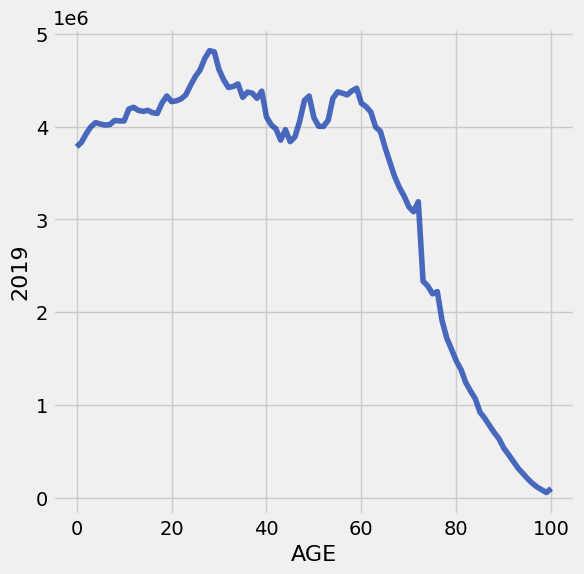

In [7]:
overall.plot("AGE", "2019")

In [8]:
males = below_999.where("SEX", 1).drop("SEX")
females = below_999.where("SEX", 2).drop("SEX")
males

AGE,2014,2019
0,2024511,1935117
1,2018511,1958585
2,2023752,2005544
3,2049250,2043010
4,2043524,2066951
5,2042790,2061200
6,2109355,2052956
7,2121426,2055735
8,2104331,2079723
9,2096379,2073148


In [9]:
pop_2019 = Table().with_columns(
    "Age", males.column("AGE"),
    "Males", males.column("2019"),
    "Females", females.column("2019")
)

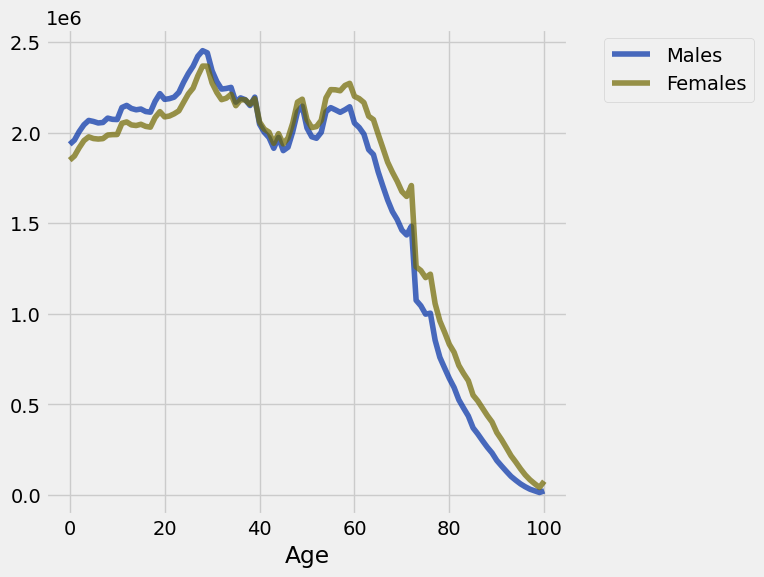

In [10]:
pop_2019.plot("Age")

In [11]:
all_age = simple.where("AGE", 999)
all_age.show(5)

SEX,AGE,2014,2019
0,999,318301008,328239523
1,999,156654424,161657324
2,999,161646584,166582199


In [12]:
perc_fem_2019 = (all_age.take(1).column("2019") / all_age.take(0).column("2019")) * 100
perc_fem_2019

array([ 49.24980469])

In [13]:
perc_ma_2019 = (all_age.take(2).column("2019") / all_age.take(0).column("2019")) * 100
perc_ma_2019

array([ 50.75019531])

In [14]:
perc_fem_2014 = (all_age.take(1).column("2014") / all_age.take(0).column("2014")) * 100
perc_fem_2014

array([ 49.21581147])

In [15]:
pop_2019

Age,Males,Females
0,1935117,1847935
1,1958585,1871014
2,2005544,1916500
3,2043010,1955655
4,2066951,1976372
5,2061200,1967081
6,2052956,1964271
7,2055735,1966584
8,2079723,1986471
9,2073148,1988726


In [16]:
total = pop_2019.column("Males") + pop_2019.column("Females")
female_percentage =( pop_2019.column("Females") / total) * 100
female_percentage

array([ 48.84772929,  48.85665575,  48.86482661,  48.90769794,
        48.87989409,  48.83177216,  48.89619133,  48.891796  ,
        48.85332574,  48.96079987,  48.98279709,  48.9638626 ,
        48.91584353,  48.91319525,  48.95759569,  48.99435008,
        49.0132324 ,  49.00202176,  48.95504446,  48.85543937,
        48.86882703,  48.87982978,  48.93202059,  48.82680386,
        48.75770556,  48.75912579,  48.69284051,  48.8521968 ,
        49.12023409,  49.23570746,  49.27026013,  49.32986637,
        49.3410954 ,  49.39558621,  49.56983336,  49.77550276,
        49.88230838,  49.98809984,  50.07964091,  49.90289454,
        50.14599374,  50.21453868,  50.37201166,  50.35627549,
        50.26558532,  50.48105622,  50.6527532 ,  50.58644103,
        50.62378332,  50.44245948,  50.55924807,  50.63152682,
        50.80644073,  50.81350976,  50.89171017,  51.13603295,
        51.27000222,  51.3678543 ,  51.52798838,  51.46621264,
        51.73196183,  51.88924675,  52.0955001 ,  52.30

(0.0, 100.0)

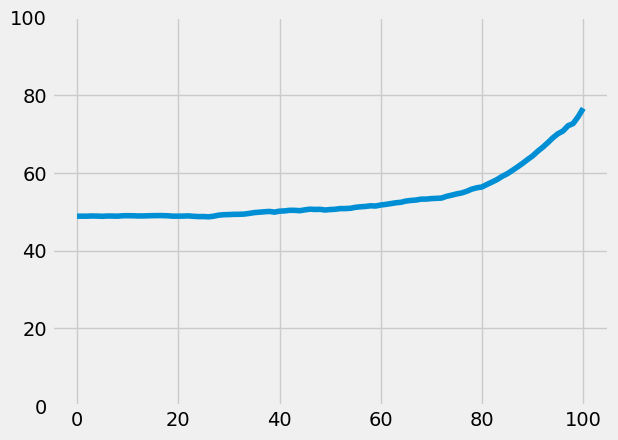

In [17]:
plots.plot(female_percentage)
plots.ylim(0, 100)

In [18]:
actors = Table.read_table("actors.csv")
actors

Actor,Total Gross,Number of Movies,Average per Movie,#1 Movie,Gross
Harrison Ford,4871.7,41,118.8,Star Wars: The Force Awakens,936.7
Samuel L. Jackson,4772.8,69,69.2,The Avengers,623.4
Morgan Freeman,4468.3,61,73.3,The Dark Knight,534.9
Tom Hanks,4340.8,44,98.7,Toy Story 3,415
"Robert Downey, Jr.",3947.3,53,74.5,The Avengers,623.4
Eddie Murphy,3810.4,38,100.3,Shrek 2,441.2
Tom Cruise,3587.2,36,99.6,War of the Worlds,234.3
Johnny Depp,3368.6,45,74.9,Dead Man's Chest,423.3
Michael Caine,3351.5,58,57.8,The Dark Knight,534.9
Scarlett Johansson,3341.2,37,90.3,The Avengers,623.4


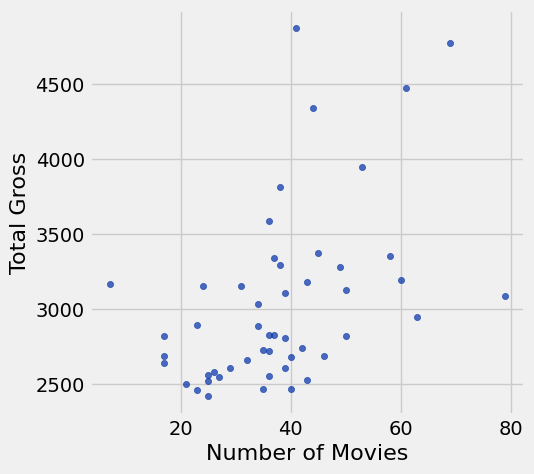

In [19]:
actors.scatter("Number of Movies", "Total Gross")

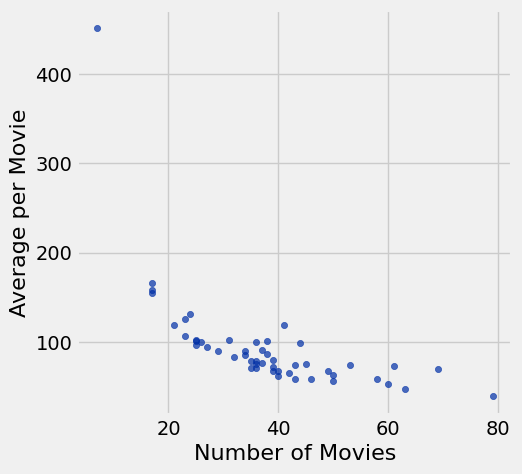

In [20]:
actors.scatter("Number of Movies", "Average per Movie")

In [21]:
actors.sort("Average per Movie", descending=True).take(0)

Actor,Total Gross,Number of Movies,Average per Movie,#1 Movie,Gross
Anthony Daniels,3162.9,7,451.8,Star Wars: The Force Awakens,936.7


In [22]:
top_movies = Table.read_table("top_movies_2017.csv")
top_movies

Title,Studio,Gross,Gross (Adjusted),Year
Gone with the Wind,MGM,198676459,1796176700,1939
Star Wars,Fox,460998007,1583483200,1977
The Sound of Music,Fox,158671368,1266072700,1965
E.T.: The Extra-Terrestrial,Universal,435110554,1261085000,1982
Titanic,Paramount,658672302,1204368000,1997
The Ten Commandments,Paramount,65500000,1164590000,1956
Jaws,Universal,260000000,1138620700,1975
Doctor Zhivago,MGM,111721910,1103564200,1965
The Exorcist,Warner Brothers,232906145,983226600,1973
Snow White and the Seven Dwarves,Disney,184925486,969010000,1937


In [23]:
top_10_adjusted = top_movies.take(np.arange(10))
top_10_adjusted

Title,Studio,Gross,Gross (Adjusted),Year
Gone with the Wind,MGM,198676459,1796176700,1939
Star Wars,Fox,460998007,1583483200,1977
The Sound of Music,Fox,158671368,1266072700,1965
E.T.: The Extra-Terrestrial,Universal,435110554,1261085000,1982
Titanic,Paramount,658672302,1204368000,1997
The Ten Commandments,Paramount,65500000,1164590000,1956
Jaws,Universal,260000000,1138620700,1975
Doctor Zhivago,MGM,111721910,1103564200,1965
The Exorcist,Warner Brothers,232906145,983226600,1973
Snow White and the Seven Dwarves,Disney,184925486,969010000,1937


In [24]:
millions = np.round(top_10_adjusted.column("Gross (Adjusted)") / 1000000, 3)
top_10_adjusted = top_10_adjusted.with_column("Millions", millions)
top_10_adjusted

Title,Studio,Gross,Gross (Adjusted),Year,Millions
Gone with the Wind,MGM,198676459,1796176700,1939,1796.18
Star Wars,Fox,460998007,1583483200,1977,1583.48
The Sound of Music,Fox,158671368,1266072700,1965,1266.07
E.T.: The Extra-Terrestrial,Universal,435110554,1261085000,1982,1261.09
Titanic,Paramount,658672302,1204368000,1997,1204.37
The Ten Commandments,Paramount,65500000,1164590000,1956,1164.59
Jaws,Universal,260000000,1138620700,1975,1138.62
Doctor Zhivago,MGM,111721910,1103564200,1965,1103.56
The Exorcist,Warner Brothers,232906145,983226600,1973,983.227
Snow White and the Seven Dwarves,Disney,184925486,969010000,1937,969.01


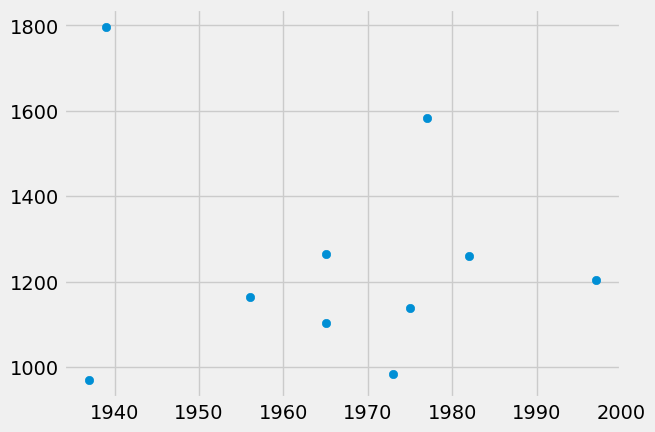

In [28]:
top_10_adjusted.sort("Year")
plots.scatter(top_10_adjusted.column("Year"), top_10_adjusted.column("Millions"))

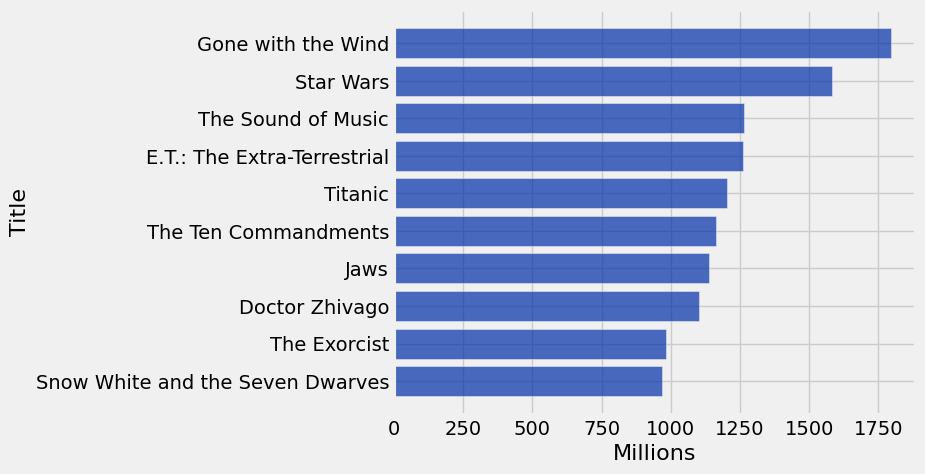

In [31]:
top_10_adjusted.barh("Title", "Millions")